# Critical Path for Data Quality, Consistency Alignment, and Pre-Clustering Feature Selection

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../EDAgroup5/data/g5_sample_flip.csv")

## **Systemic Null Value Resolution**

Define and execute an explicit, domain-justified rule for every missing value pattern identified in the panel dataset:

## Structural NULL handling

General rule applied to **every** imputed column: add a boolean
`_was_missing` flag **before** filling. 

In [18]:
imp_log = {}          
df_c = df.copy()

def impute(col, value, rule, add_flag=True, fill_label=None):
    if col not in df_c.columns:
        return
    n = int(df_c[col].isna().sum())
    if add_flag:
        df_c[col + "_was_missing"] = df_c[col].isna()
    df_c[col] = df_c[col].fillna(value)
    if fill_label is None:
        fill_label = value if np.isscalar(value) else "<vectorised>"
    imp_log[col] = {"rule": rule, "fill": fill_label, "n_filled": n, "flag": f"{col}_was_missing" if add_flag else None}

### Group E — historical context

* **`*_avg_prev3m`** — user has no 3-month history yet. Neutral fill = the
  **current-month analogue** when one exists (best available estimate of the
  user's recent level), else the column median. A single `is_history_seed`
  flag marks these rows.
* **`*_delta_m`** — change vs. 3m average is genuinely *0* information when there
  is no baseline → fill **0**.
* **`spend_velocity_index_m`** — ratio-type index → fill **1.0** (neutral "no
  acceleration"), flagged.

In [19]:
LAG_ANALOGUE = {                       # prev3m feature  ->  current-month analogue
    "tx_count_avg_prev3m":           "tx_count_m",
    "tx_amount_avg_prev3m":          "tx_amount_avg_m",
    "oxxo_ratio_avg_prev3m":         "oxxo_tx_ratio_m",
    "cash_funding_ratio_avg_prev3m": "cash_funding_ratio_m",
    "ecommerce_ratio_avg_prev3m":    "ecommerce_tx_ratio_m",
}

if "tx_count_avg_prev3m" in df_c.columns:
    df_c["is_history_seed"] = df_c["tx_count_avg_prev3m"].isna()
else:
    df_c["is_history_seed"] = False

for lag_col, cur_col in LAG_ANALOGUE.items():
    if lag_col in df_c.columns and cur_col in df_c.columns:
        fill = df_c[cur_col].astype(float)
        fill = fill.fillna(fill.median())
        impute(lag_col, fill, f"first-3-months: fill with current-month analogue '{cur_col}', else median", 
               add_flag=False, fill_label=f"current-month analogue '{cur_col}' (residual -> median)")

for d in ["tx_count_delta_m","tx_amount_avg_delta_m","oxxo_ratio_delta_m",
          "cash_funding_ratio_delta_m","ecommerce_ratio_delta_m"]:
    if d in df_c.columns:
        impute(d, 0.0, "no 3m baseline -> delta carries no signal -> 0", add_flag=False)

if "spend_velocity_index_m" in df_c.columns:
    impute("spend_velocity_index_m", 1.0, "neutral 'no acceleration' index value")

print("Group E done. history-seed rows:", int(df_c['is_history_seed'].sum()))

Group E done. history-seed rows: 0


## Group F — friction & recovery

* **`recovery_avg_min_m`** NULL ⇒ *there was nothing to recover from* (no decline,
  or no post-decline success). This is **not** a large latency — fill **0** and
  expose `had_decline_m` + `recovery_avg_min_m_was_missing`.
* **`top_rejection_reason_m`** NULL ⇒ no decline → explicit category **`"NONE"`**.
* **`oxxo_decline_ratio_m` / `same_merchant_retry_ratio_m`** — already 0-filled in
  source for no-decline users.

In [20]:
if "decline_count_m" in df_c.columns:
    df_c["had_decline_m"] = df_c["decline_count_m"].fillna(0).gt(0)
else:
    df_c["had_decline_m"] = False

if "recovery_avg_min_m" in df_c.columns:
    impute("recovery_avg_min_m", 0.0, "NULL = no decline or no post-decline success -> 0 min, keep flag + had_decline_m")

if "top_rejection_reason_m" in df_c.columns:
    df_c["top_rejection_reason_m"] = (
        df_c["top_rejection_reason_m"].astype('category').cat.add_categories(["NONE"]).fillna("NONE")
    )
    imp_log["top_rejection_reason_m"] = {
        "rule": "NULL = no declined tx -> category 'NONE'",
        "fill": "NONE", 
        "n_filled": int(df["top_rejection_reason_m"].isna().sum()) if "top_rejection_reason_m" in df.columns else 0,
        "flag": None
    }
    print(df_c["top_rejection_reason_m"].value_counts().head(6))

# Pilar 2

## Zero-Activity vs. Ratio Alignment:
* **`oxxo_tx_ratio_m`** / **`ecommerce_tx_ratio_m`**: When a user has zero transaction activity (tx_count_m == 0), spending ratios render as undefined or zero-division anomalies. Force all channel ratios to 0.0 when transaction volume is zero, keeping the missingness flag consistent to explicitly mark inactive months.

In [21]:
if "tx_count_m" in df_c.columns:
    zero_tx_mask = df_c['tx_count_m'] == 0
    target_ratios = [c for c in ['oxxo_tx_ratio_m', 'ecommerce_tx_ratio_m'] if c in df_c.columns]
    if target_ratios:
        df_c.loc[zero_tx_mask, target_ratios] = 0.0

## Spend vs. Funding Discrepancies:
* **`spend_to_fund_ratio_m`**: When total monthly funding is zero (funding_amount_total_m == 0), calculating ratio metrics against total spend (tx_amount_sum_m) generates division-by-zero or infinite values. Force spend_to_fund_ratio_m to 0.0 (or a capped extreme upper limit if spend exists without new funding) and create a boolean flag is_zero_funding_m to capture this financial state.

In [22]:
if "funding_amount_total_m" in df_c.columns:
    df_c["is_zero_funding_m"] = df_c["funding_amount_total_m"] == 0
    if "tx_amount_sum_m" in df_c.columns and "spend_to_fund_ratio_m" in df_c.columns:
        zero_funding_and_spend = df_c["is_zero_funding_m"] & (df_c["tx_amount_sum_m"].fillna(0) == 0)
        df_c.loc[zero_funding_and_spend, "spend_to_fund_ratio_m"] = 0.0

## Delta Metric Consistency:
* **`oxxo_ratio_delta_m`** / **`tx_count_delta_m`**: Delta features must mathematically match the difference between current monthly values and historical averages (tx_count_m - tx_count_avg_prev3m). Recalculate and overwrite these columns directly from the reconciled source features to guarantee alignment across all panel records.

In [23]:
if "tx_count_m" in df_c.columns and "tx_count_avg_prev3m" in df_c.columns:
    df_c["tx_count_delta_m"] = df_c["tx_count_m"] - df_c["tx_count_avg_prev3m"]

if "oxxo_tx_ratio_m" in df_c.columns and "oxxo_ratio_avg_prev3m" in df_c.columns:
    df_c["oxxo_ratio_delta_m"] = df_c["oxxo_tx_ratio_m"] - df_c["oxxo_ratio_avg_prev3m"]

In [24]:
if "tx_count_m" in df_c.columns:
    print(f"• Zero-activity rows aligned (ratios set to 0.0): {int(zero_tx_mask.sum())}")
if "is_zero_funding_m" in df_c.columns:
    print(f"• Zero-funding records flagged & neutralized: {int(df_c['is_zero_funding_m'].sum())}")
print(f"• {len(df_c)} total rows")

• Zero-activity rows aligned (ratios set to 0.0): 693322
• 814179 total rows


## Remaining NULLs — recalculate where the formula is known, else impute

The NaN-rate of every column below is **flat across `tx_count_m` quartiles**, i.e.
the missingness is **MCAR** (injected noise), not a structural signal.

| column | status | fill |
|---|---|---|
| `spend_to_fund_ratio_m` | closed form | `tx_amount_sum_m / funding_amount_total_m` (denominator never 0) |
| `spending_dispersion_ratio_m` | closed form | `tx_amount_p90_m / tx_amount_p10_m` (`p10` never 0) |
| `tx_amount_stddev_m` | no raw tx amounts to rebuild it | `0` when `tx_count_m <= 1` (undefined), else column median |
| `intertx_avg_min_m` | not recomputable | `0` when `tx_count_m <= 1` (no interval), else median |
| `intertx_cv_m` | `= STDDEV(inter-tx) / intertx_avg_min_m`, numerator missing | `0` when `tx_count_m <= 1`, else median |
| `oxxo_amount_ratio_m` | no `SUM(oxxo amount)` column | no recalculation possible, flagged
| `top_mcc_m` | categorical (excluded from numeric corr) | `"UNKNOWN"` |

Median (not `0`) is used for the MCAR gaps so the correlation matrix is not
distorted by an artificial spike at 0. Every touched column keeps a
`*_was_missing` flag.


In [25]:
single_tx = df_c["tx_count_m"] <= 1 if "tx_count_m" in df_c.columns else pd.Series(False, index=df_c.index)

# 1. Closed-form recomputation
if "spend_to_fund_ratio_m" in df_c.columns and "tx_amount_sum_m" in df_c.columns and "funding_amount_total_m" in df_c.columns:
    impute("spend_to_fund_ratio_m",
           df_c["tx_amount_sum_m"] / df_c["funding_amount_total_m"].replace(0, np.nan),
           "closed form: tx_amount_sum_m / funding_amount_total_m",
           fill_label="tx_amount_sum_m / funding_amount_total_m")

if "spending_dispersion_ratio_m" in df_c.columns and "tx_amount_p90_m" in df_c.columns and "tx_amount_p10_m" in df_c.columns:
    impute("spending_dispersion_ratio_m",
           df_c["tx_amount_p90_m"] / df_c["tx_amount_p10_m"].replace(0, np.nan),
           "closed form: tx_amount_p90_m / tx_amount_p10_m",
           fill_label="tx_amount_p90_m / tx_amount_p10_m")

# 2. Not recomputable -> 0 when mathematically undefined, else median 
for col in ["tx_amount_stddev_m", "intertx_avg_min_m", "intertx_cv_m"]:
    if col in df_c.columns:
        n = int(df_c[col].isna().sum())
        med = df_c[col].median()
        df_c[col + "_was_missing"] = df_c[col].isna()
        df_c[col] = df_c[col].mask(df_c[col].isna() & single_tx, 0.0).fillna(med)
        imp_log[col] = {"rule": "undefined for <=1 tx -> 0 ; MCAR gap -> median",
                        "fill": f"0 / median({med:.4g})", "n_filled": n,
                        "flag": f"{col}_was_missing"}

# 3. oxxo_amount_ratio_m: proxy fallback
if "oxxo_amount_ratio_m" in df_c.columns and "oxxo_tx_ratio_m" in df_c.columns:
    oxxo_cnt = df_c["oxxo_tx_count_m"] if "oxxo_tx_count_m" in df_c.columns else 0
    impute("oxxo_amount_ratio_m",
           df_c["oxxo_tx_ratio_m"].where(oxxo_cnt > 0, 0.0),
           "no SUM(oxxo amount): 0 when oxxo_tx_count_m==0 else oxxo_tx_ratio_m proxy",
           fill_label="0 / oxxo_tx_ratio_m proxy")

# 4. top_mcc_m: categorical
if "top_mcc_m" in df_c.columns:
    df_c["top_mcc_m"] = (df_c["top_mcc_m"].astype("category")
                         .cat.add_categories(["UNKNOWN"]).fillna("UNKNOWN"))
    imp_log["top_mcc_m"] = {"rule": "MCAR gap in categorical -> 'UNKNOWN'", "fill": "UNKNOWN",
                            "n_filled": int(df["top_mcc_m"].isna().sum()), "flag": None}

# Verificación final de nulos residuales
_left = df_c.isna().sum()
print("remaining NaNs:", int(_left.sum()))
print(_left[_left > 0].to_string() if _left.sum() else "clean")

remaining NaNs: 4291996
cash_funding_ratio_m             685467
spend_to_fund_ratio_m            685467
oxxo_ratio_change_next_m         718854
ticket_change_next_m             718859
target_flip_out_30d               81385
target_flip_in_liquidity_30d     700982
target_flip_in_commercial_30d    700982


## Numeric correlation — dependency & redundancy on fully-valid data

All NaNs are resolved above, so the Spearman matrix below is computed on complete
cases. IDs, month key, `*_next_m` / `target_*` leakage columns, boolean flags and
constant columns are excluded. Pairs with `|rho| >= 0.90` are listed as redundancy
candidates.

17 numeric features in the correlation matrix

7 redundant pairs (|Spearman rho| >= 0.90):
  -0.999   cash_funding_ratio_m  <->  spei_amount_m
  +0.999   tx_count_m  <->  unique_mcc_m
  +0.998   tx_count_m  <->  tx_amount_sum_m
  +0.998   tx_amount_sum_m  <->  unique_mcc_m
  +0.997   tx_amount_sum_m  <->  tx_amount_avg_m
  +0.994   tx_amount_avg_m  <->  unique_mcc_m
  +0.992   tx_count_m  <->  tx_amount_avg_m


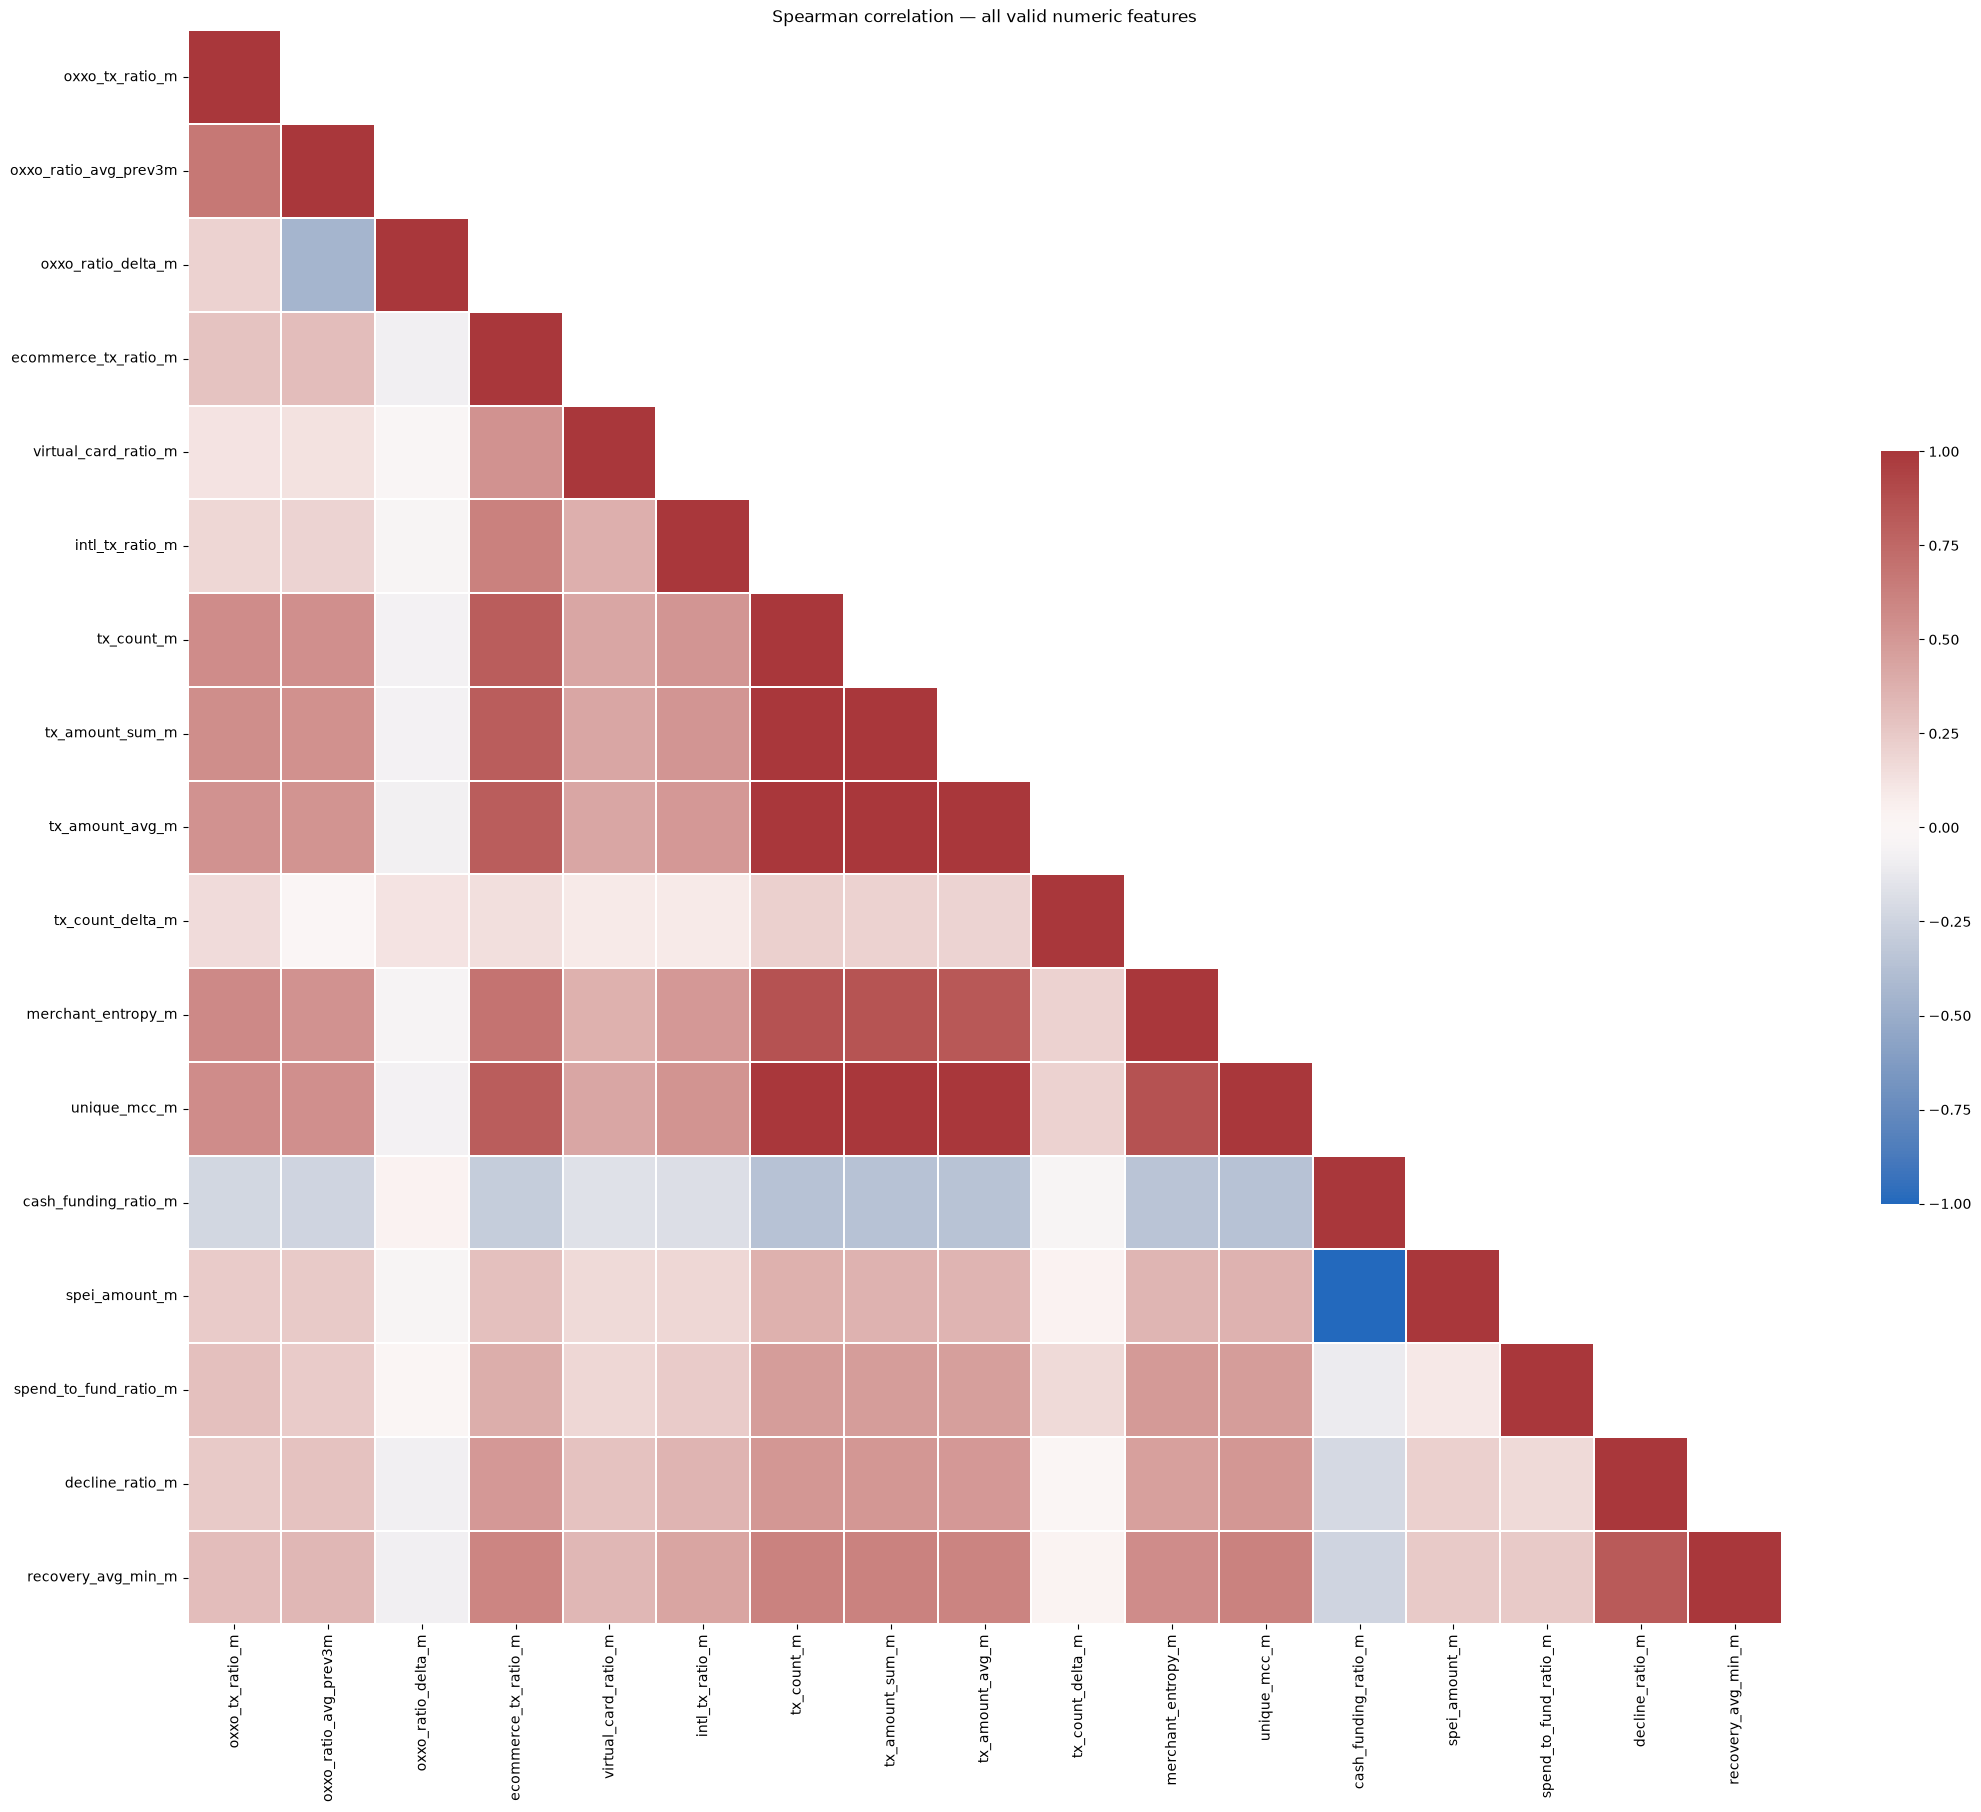

In [26]:
for col in df_c.columns:
    if df_c[col].isna().sum() > 0:
        if np.issubdtype(df_c[col].dtype, np.number):
            med = df_c[col].median()
            df_c[col] = df_c[col].fillna(med if pd.notna(med) else 0)
        else:
            df_c[col] = df_c[col].fillna("UNKNOWN")

# Exclusión explícita por patrones de nombre (IDs, Fechas, Leakage/Targets)
leakage_patterns = ['_next_m', 'target_']
known_id_cols = {'userid', 'user_id', 'id', 'customer_id', 'mes', 'month', 'month_key', 'gender', 'age_years'}

# Base numérica seleccionada
num = df_c.select_dtypes(include=[np.number]).copy()

# [CAMBIO 3]: Filtrado dinámico de columnas no deseadas (flags, IDs, variables auxiliares)
cols_to_drop = []
for col in num.columns:
    c_lower = col.lower()
    # Identificadores / Claves
    if c_lower in known_id_cols or 'id' in c_lower or 'month' in c_lower:
        cols_to_drop.append(col)
    # Variables de Fuga (Leakage)
    elif any(p in c_lower for p in leakage_patterns):
        cols_to_drop.append(col)
    # Indicadores booleanos e imputaciones (_was_missing, flags de estado)
    elif col.endswith("_was_missing") or col.startswith("is_") or col.startswith("had_"):
        cols_to_drop.append(col)

num = num.drop(columns=list(set(cols_to_drop)), errors='ignore')
num = num.loc[:, num.nunique() > 1]  # Remover constantes sin varianza

print(f"{num.shape[1]} numeric features in the correlation matrix")

# Matriz de correlación de Spearman
corr = num.corr("spearman")

# Búsqueda de pares redundantes (|rho| >= 0.90) usando bucles nativos (sin itertools)
cols = corr.columns
redundant = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = corr.iloc[i, j]
        if abs(val) >= 0.90:
            redundant.append((cols[i], cols[j], val))

redundant.sort(key=lambda t: -abs(t[2]))

print(f"\n{len(redundant)} redundant pairs (|Spearman rho| >= 0.90):")
for a, b, r in redundant:
    print(f"  {r:+.3f}   {a}  <->  {b}")

# Visualización del mapa de calor
fig, ax = plt.subplots(figsize=(22, 20))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, square=True,
            xticklabels=True, yticklabels=True, linewidths=.3,
            cbar_kws={"shrink": .4}, ax=ax)
ax.set_title("Spearman correlation — all valid numeric features")
plt.tight_layout()
plt.show()